In [58]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.inspection import permutation_importance

In [59]:
def get_series(df, col):
    s = df[col]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    return s.copy()


def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    return 100 - (100 / (1 + rs))


def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()


def atr(df, period=14):
    high = get_series(df, "High")
    low = get_series(df, "Low")
    close = get_series(df, "Adj Close")

    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return true_range.rolling(period).mean()


def stochastic_oscillator(df, period=14):
    high = get_series(df, "High")
    low = get_series(df, "Low")
    close = get_series(df, "Adj Close")

    lowest_low = low.rolling(period).min()
    highest_high = high.rolling(period).max()

    return 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-12)

In [60]:
def make_features(df):
    if "Adj Close" not in df.columns:
        raise ValueError("Missing 'Adj Close' column")

    price = get_series(df, "Adj Close")
    volume = get_series(df, "Volume")
    ret = price.pct_change()

    feat = pd.DataFrame(index=df.index)

    feat["ret1"] = ret
    feat["ret_5"] = price.pct_change(5)
    feat["ret_10"] = price.pct_change(10)
    feat["ret_20"] = price.pct_change(20)

    for k in range(1, 11):
        feat[f"ret_lag_{k}"] = ret.shift(k)

    feat["ma_5"] = price.rolling(5).mean()
    feat["ma_10"] = price.rolling(10).mean()
    feat["ma_20"] = price.rolling(20).mean()
    feat["ma_50"] = price.rolling(50).mean()

    feat["ema_12"] = ema(price, 12)
    feat["ema_26"] = ema(price, 26)

    feat["mom_10"] = price / feat["ma_10"] - 1
    feat["mom_20"] = price / feat["ma_20"] - 1
    feat["mom_50"] = price / feat["ma_50"] - 1

    feat["vol_5"] = ret.rolling(5).std()
    feat["vol_10"] = ret.rolling(10).std()
    feat["vol_20"] = ret.rolling(20).std()

    feat["rsi_14"] = rsi(price, 14)
    feat["macd"] = feat["ema_12"] - feat["ema_26"]
    feat["atr_14"] = atr(df, 14)
    feat["stoch_14"] = stochastic_oscillator(df, 14)

    vol_ma_20 = volume.rolling(20).mean()
    feat["vol_ratio"] = volume / (vol_ma_20 + 1e-12)

    ma = price.rolling(20).mean()
    std = price.rolling(20).std()
    upper = ma + 2 * std
    lower = ma - 2 * std
    feat["bollinger_width"] = (upper - lower) / (ma + 1e-12)
    feat["zscore_20"] = (price - ma) / (std + 1e-12)

    feat["target_next_ret"] = ret.shift(-1)
    feat["target_direction"] = (feat["target_next_ret"] > 0).astype(int)
    feat["price"] = price

    return feat.dropna()

In [61]:
def direction_accuracy(y_true, y_pred):
    return ((np.array(y_pred) > 0) == (np.array(y_true) > 0)).mean()


def report_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    dir_acc = direction_accuracy(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE (return): {mae:.6f}")
    print(f"R2  (return): {r2:.6f}")
    print(f"Direction accuracy: {dir_acc * 100:.2f}%")


def sharpe_ratio(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    return np.sqrt(periods_per_year) * returns.mean() / (returns.std() + 1e-12)


def max_drawdown(cumulative_returns):
    cumulative_returns = pd.Series(cumulative_returns)
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown.min()


def annualized_return(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    cumulative = (1 + returns).prod()
    n = len(returns)
    return cumulative ** (periods_per_year / n) - 1

In [62]:
ticker = "NVDA"
df = yf.download(ticker, period="10y", auto_adjust=False)

if df.empty:
    raise ValueError("No data downloaded. Try a different ticker or timeframe.")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,
2016-03-17,0.803438,0.82050,0.82850,0.80925,0.82450,353680000
2016-03-18,0.827673,0.84525,0.85625,0.82500,0.83025,545512000
2016-03-21,0.830121,0.84775,0.84800,0.82875,0.83775,337780000
2016-03-22,0.828652,0.84625,0.85225,0.83575,0.84500,242012000
2016-03-23,0.842850,0.86075,0.86700,0.84625,0.85000,429008000


In [63]:
feat = make_features(df)
feat.head()

,ret1,ret_5,ret_10,ret_20,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_lag_6,...,rsi_14,macd,atr_14,stoch_14,vol_ratio,bollinger_width,zscore_20,target_next_ret,target_direction,price
Date,,,,,,,,,,,,,,,,,,,,,
2016-05-26,0.010626,0.050942,0.286717,0.264324,-0.004189,0.024275,0.001578,0.017911,0.004382,0.025544,...,93.861201,0.063520,0.048517,89.473032,0.619940,0.442613,1.399127,0.005477,1,1.120419
2016-05-27,0.005477,0.038104,0.122967,0.295221,0.010626,-0.004189,0.024275,0.001578,0.017911,0.004382,...,94.376228,0.065133,0.048836,91.694230,0.557323,0.447727,1.304166,0.017865,1,1.126555
2016-05-31,0.017865,0.054985,0.110247,0.301148,0.005477,0.010626,-0.004189,0.024275,0.001578,0.017911,...,94.441526,0.067260,0.049343,91.987051,0.815929,0.453978,1.329714,0.001926,1,1.146682
2016-06-01,0.001926,0.031967,0.110018,0.319414,0.017865,0.005477,0.010626,-0.004189,0.024275,0.001578,...,94.437086,0.068337,0.049602,89.421097,0.753551,0.451073,1.217172,0.007050,1,1.148890
2016-06-02,0.007050,0.043613,0.090001,0.359679,0.001926,0.017865,0.005477,0.010626,-0.004189,0.024275,...,98.422230,0.069048,0.049663,85.241166,0.653300,0.436597,1.174409,-0.014001,0,1.156990


In [64]:
feat.shape

(2463, 36)

In [65]:
feature_cols = [c for c in feat.columns if c not in ["target_next_ret", "target_direction", "price"]]
X = feat[feature_cols]
y = feat["target_next_ret"].values
y_dir = feat["target_direction"].values

split = int(len(feat) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y[:split], y[split:]
y_train_dir, y_test_dir = y_dir[:split], y_dir[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1970, 33)
Test shape: (493, 33)


In [66]:
pred_zero = np.zeros_like(y_test)
pred_naive = X_test["ret1"].values
pred_mean = np.full_like(y_test, y_train.mean())

report_regression("Baseline: Zero return", y_test, pred_zero)
report_regression("Baseline: Naive (predict today's return)", y_test, pred_naive)
report_regression("Baseline: Train mean return", y_test, pred_mean)


Baseline: Zero return
MAE (return): 0.022722
R2  (return): -0.003612
Direction accuracy: 46.65%

Baseline: Naive (predict today's return)
MAE (return): 0.033368
R2  (return): -1.225027
Direction accuracy: 45.03%

Baseline: Train mean return
MAE (return): 0.022627
R2  (return): -0.000763
Direction accuracy: 53.35%


In [67]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
report_regression("Ridge", y_test, pred_ridge)


Ridge
MAE (return): 0.024704
R2  (return): -0.146416
Direction accuracy: 52.33%


In [68]:
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", 0.5, 0.8]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
pred_rf = rf.predict(X_test)

print("Best Random Forest params:", rf_search.best_params_)
print("Best Random Forest CV MAE:", -rf_search.best_score_)
report_regression("Random Forest (Tuned)", y_test, pred_rf)

Best Random Forest params: {'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 6}
Best Random Forest CV MAE: 0.023597051616210472

Random Forest (Tuned)
MAE (return): 0.022802
R2  (return): -0.013139
Direction accuracy: 51.72%


In [69]:
clf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", 0.5, 0.8]
}

clf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=clf_param_grid,
    n_iter=12,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

clf_search.fit(X_train, y_train_dir)
clf = clf_search.best_estimator_
pred_dir = clf.predict(X_test)
proba_up = clf.predict_proba(X_test)[:, 1]

print("Best Classifier params:", clf_search.best_params_)
print("Best Classifier CV Accuracy:", clf_search.best_score_)
print("\nDirection Classification")
print("Test Accuracy:", accuracy_score(y_test_dir, pred_dir))
print(classification_report(y_test_dir, pred_dir, digits=4))

Best Classifier params: {'n_estimators': 600, 'min_samples_leaf': 10, 'max_features': 0.8, 'max_depth': 6}
Best Classifier CV Accuracy: 0.521341463414634

Direction Classification
Test Accuracy: 0.5314401622718052
              precision    recall  f1-score   support

           0     0.4872    0.0826    0.1413       230
           1     0.5352    0.9240    0.6778       263

    accuracy                         0.5314       493
   macro avg     0.5112    0.5033    0.4095       493
weighted avg     0.5128    0.5314    0.4275       493



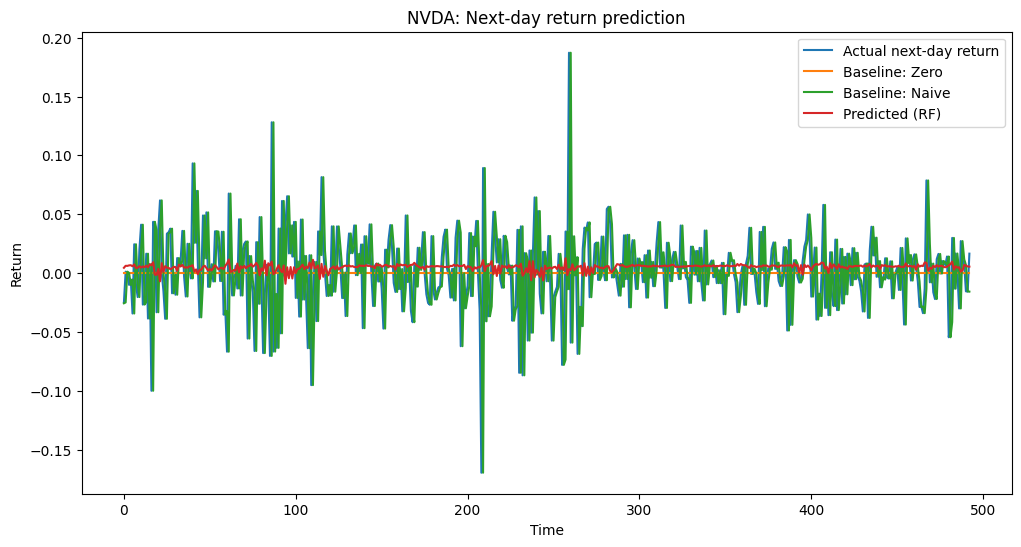

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual next-day return")
plt.plot(pred_zero, label="Baseline: Zero")
plt.plot(pred_naive, label="Baseline: Naive")
plt.plot(pred_rf, label="Predicted (RF)")
plt.title(f"{ticker}: Next-day return prediction")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show()

In [71]:
latest_X = X.iloc[[-1]]
latest_price = float(feat["price"].iloc[-1])

tomorrow_ret = float(rf.predict(latest_X)[0])
tomorrow_price = latest_price * (1 + tomorrow_ret)

print(f"Latest price: {latest_price:.2f}")
print(f"Predicted next-day return (RF): {tomorrow_ret:.6f}")
print(f"Predicted next-day price (RF): {tomorrow_price:.2f}")

Latest price: 180.25
Predicted next-day return (RF): 0.005451
Predicted next-day price (RF): 181.23


In [72]:
results_df = pd.DataFrame([
    {
        "Model": "Baseline: Zero return",
        "MAE": mean_absolute_error(y_test, pred_zero),
        "R2": r2_score(y_test, pred_zero),
        "Direction Accuracy": direction_accuracy(y_test, pred_zero)
    },
    {
        "Model": "Baseline: Naive",
        "MAE": mean_absolute_error(y_test, pred_naive),
        "R2": r2_score(y_test, pred_naive),
        "Direction Accuracy": direction_accuracy(y_test, pred_naive)
    },
    {
        "Model": "Baseline: Train mean",
        "MAE": mean_absolute_error(y_test, pred_mean),
        "R2": r2_score(y_test, pred_mean),
        "Direction Accuracy": direction_accuracy(y_test, pred_mean)
    },
    {
        "Model": "Ridge",
        "MAE": mean_absolute_error(y_test, pred_ridge),
        "R2": r2_score(y_test, pred_ridge),
        "Direction Accuracy": direction_accuracy(y_test, pred_ridge)
    },
    {
        "Model": "Random Forest (Tuned)",
        "MAE": mean_absolute_error(y_test, pred_rf),
        "R2": r2_score(y_test, pred_rf),
        "Direction Accuracy": direction_accuracy(y_test, pred_rf)
    }
])

results_df

,Model,MAE,R2,Direction Accuracy
0,Baseline: Zero return,0.022722,-0.003612,0.466531
1,Baseline: Naive,0.033368,-1.225027,0.450304
2,Baseline: Train mean,0.022627,-0.000763,0.533469
3,Ridge,0.024704,-0.146416,0.523327
4,Random Forest (Tuned),0.022802,-0.013139,0.517241


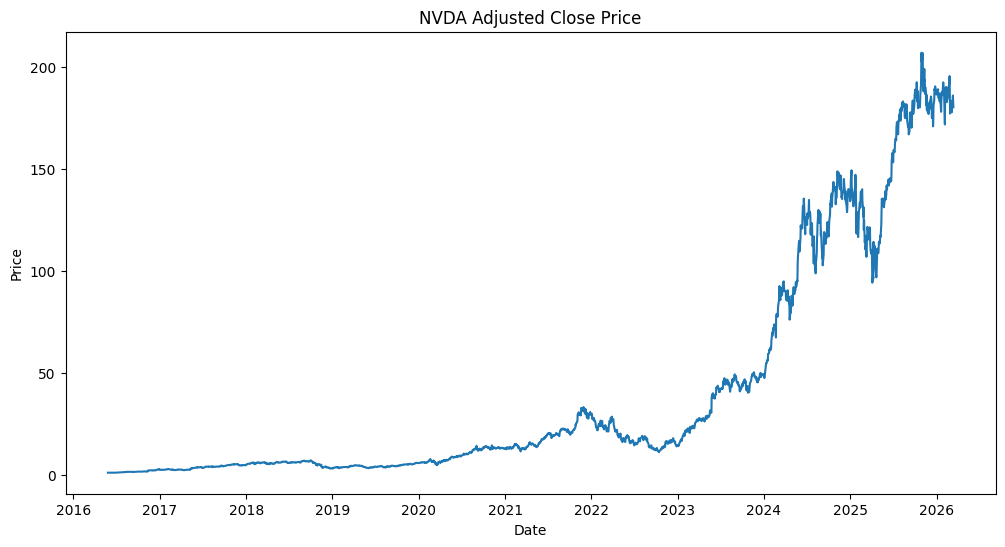

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(feat.index, feat["price"])
plt.title(f"{ticker} Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

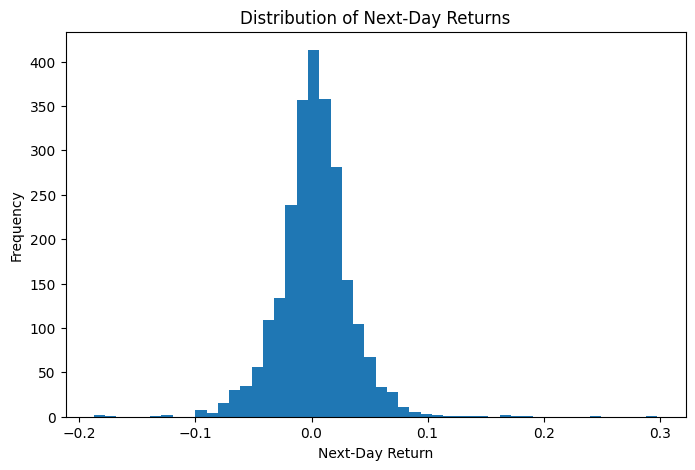

In [74]:
plt.figure(figsize=(8, 5))
plt.hist(feat["target_next_ret"], bins=50)
plt.title("Distribution of Next-Day Returns")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.show()

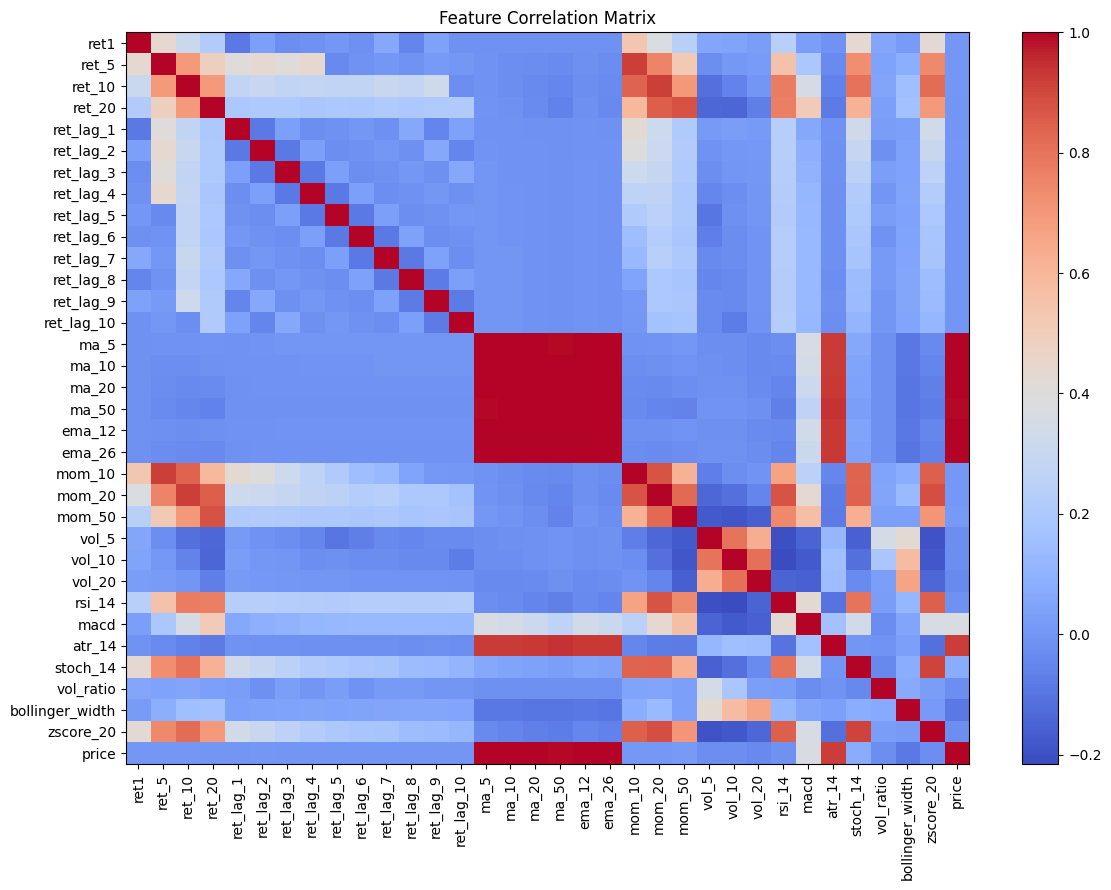

In [75]:
corr = feat.drop(columns=["target_next_ret", "target_direction"]).corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

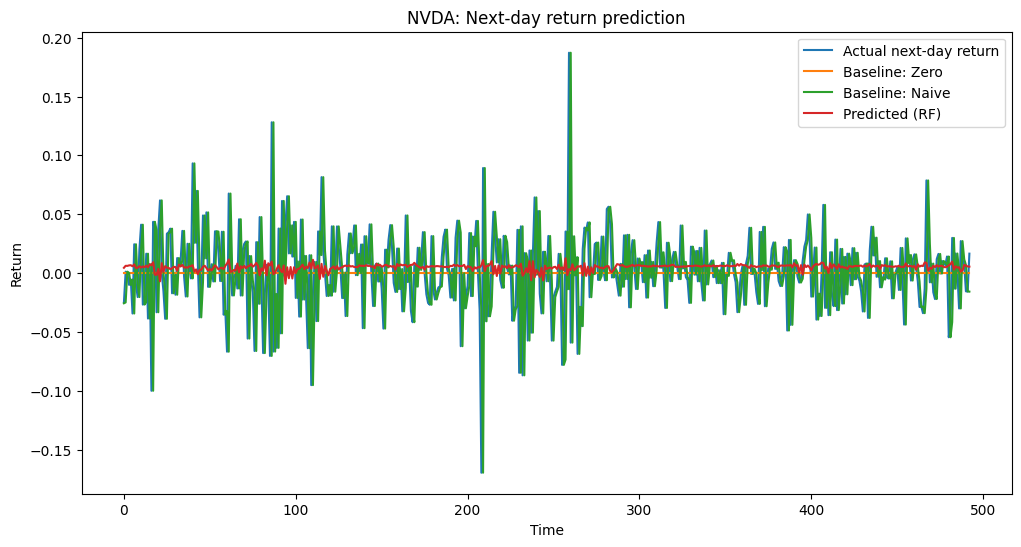

In [76]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual next-day return")
plt.plot(pred_zero, label="Baseline: Zero")
plt.plot(pred_naive, label="Baseline: Naive")
plt.plot(pred_rf, label="Predicted (RF)")
plt.title(f"{ticker}: Next-day return prediction")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show()

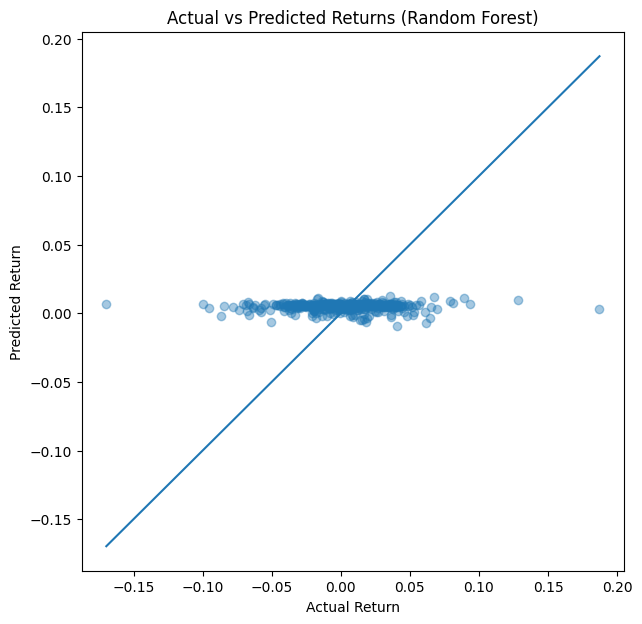

In [77]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Returns (Random Forest)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.show()

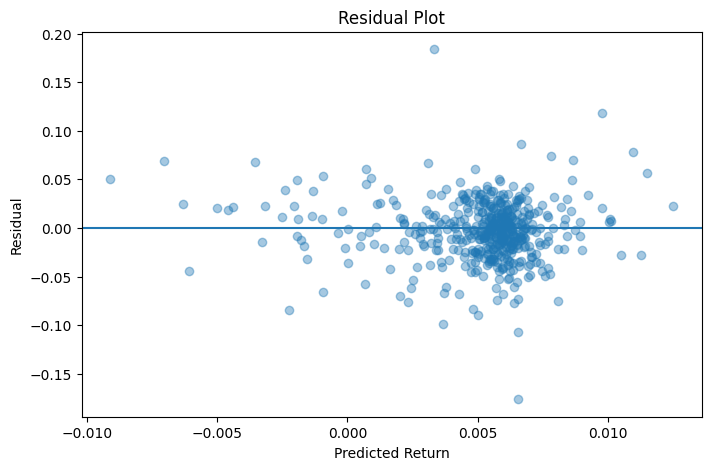

In [78]:
residuals = y_test - pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(pred_rf, residuals, alpha=0.4)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Return")
plt.ylabel("Residual")
plt.show()

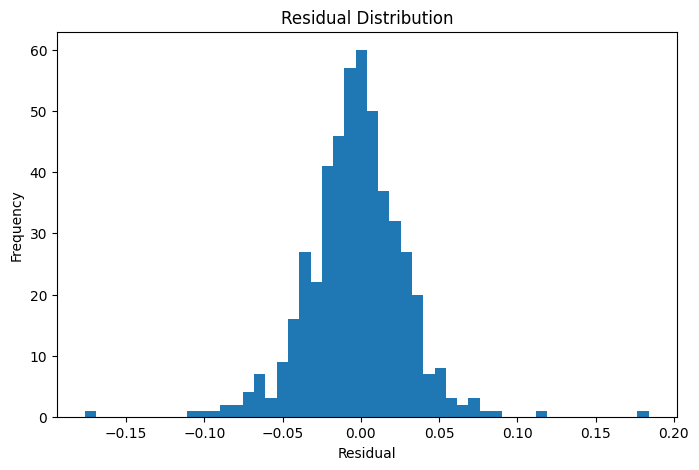

In [79]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

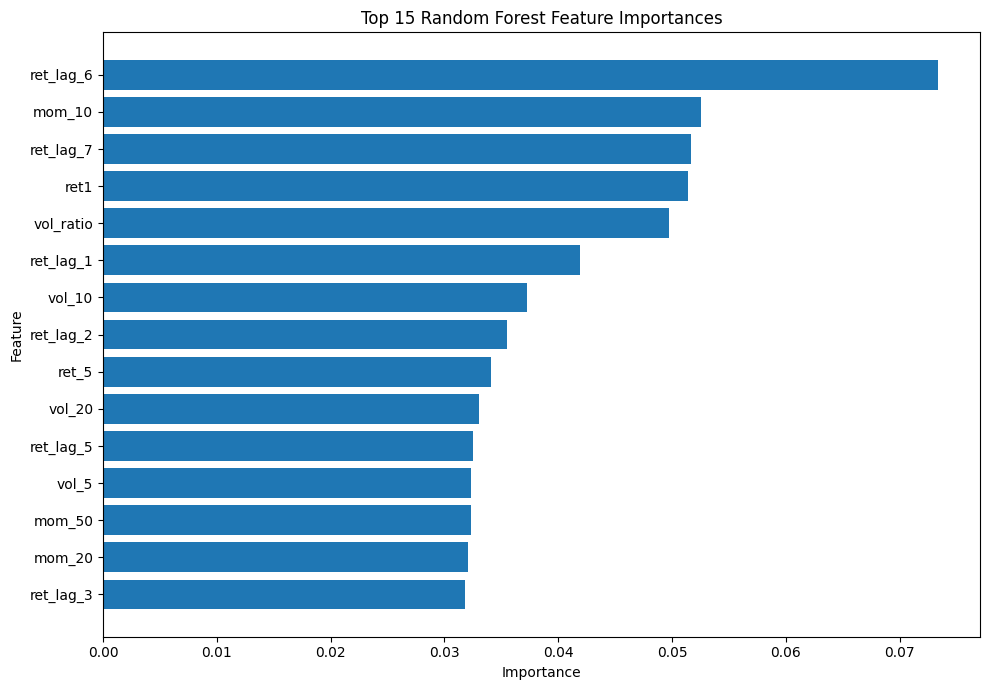

,feature,importance
9,ret_lag_6,0.073386
20,mom_10,0.052517
10,ret_lag_7,0.051659
0,ret1,0.051370
30,vol_ratio,0.049709
4,ret_lag_1,0.041925
24,vol_10,0.037244
5,ret_lag_2,0.035518
1,ret_5,0.034065
25,vol_20,0.033051


In [80]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top_features = importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.head(15)

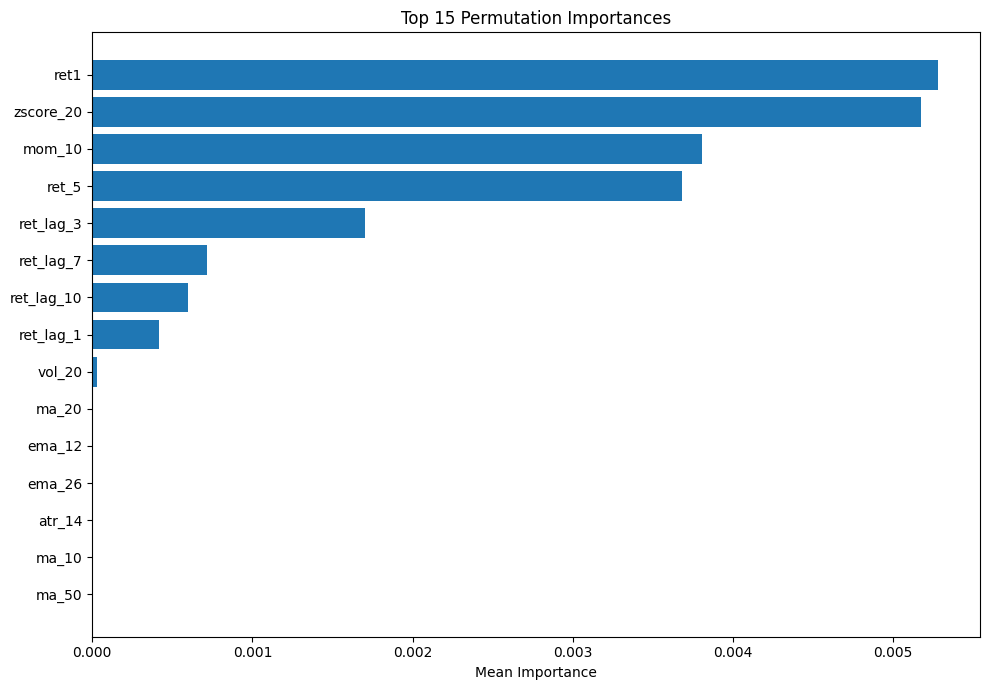

,feature,importance
0,ret1,0.005279
32,zscore_20,0.005173
20,mom_10,0.003810
1,ret_5,0.003682
6,ret_lag_3,0.001701
10,ret_lag_7,0.000715
13,ret_lag_10,0.000597
4,ret_lag_1,0.000420
25,vol_20,0.000029
17,ma_50,0.000000


In [81]:
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_top = perm_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(perm_top["feature"], perm_top["importance"])
plt.title("Top 15 Permutation Importances")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

perm_df.head(15)

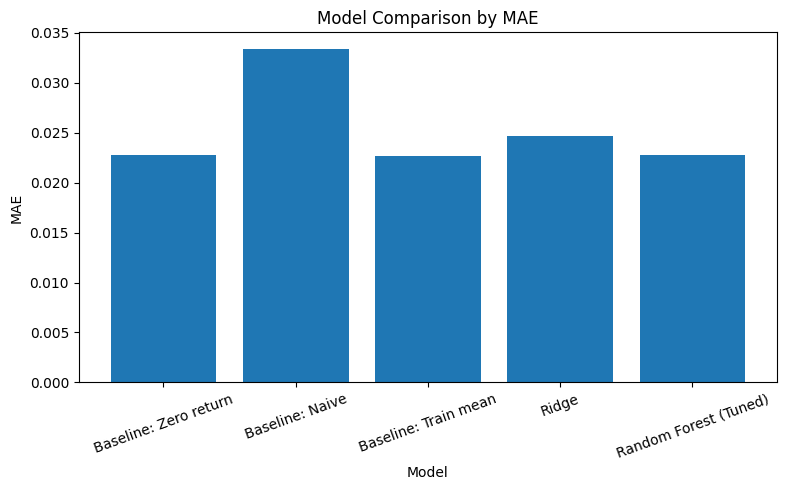

In [82]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [83]:
buy_hold_ret = pd.Series(y_test, index=X_test.index)

signal_reg = pd.Series(np.sign(pred_rf), index=X_test.index)
strategy_ret_reg = signal_reg * buy_hold_ret

long_short_signal = pd.Series(
    np.where(proba_up > 0.55, 1, np.where(proba_up < 0.45, -1, 0)),
    index=X_test.index
)

strategy_ret_prob = long_short_signal * buy_hold_ret

cost_per_trade = 0.001

turnover_reg = signal_reg.diff().abs().fillna(0)
strategy_ret_reg_net = strategy_ret_reg - turnover_reg * cost_per_trade

turnover_prob = long_short_signal.diff().abs().fillna(0)
strategy_ret_prob_net = strategy_ret_prob - turnover_prob * cost_per_trade

buy_hold_curve = (1 + buy_hold_ret).cumprod()
strategy_curve_reg = (1 + strategy_ret_reg_net).cumprod()
strategy_curve_prob = (1 + strategy_ret_prob_net).cumprod()

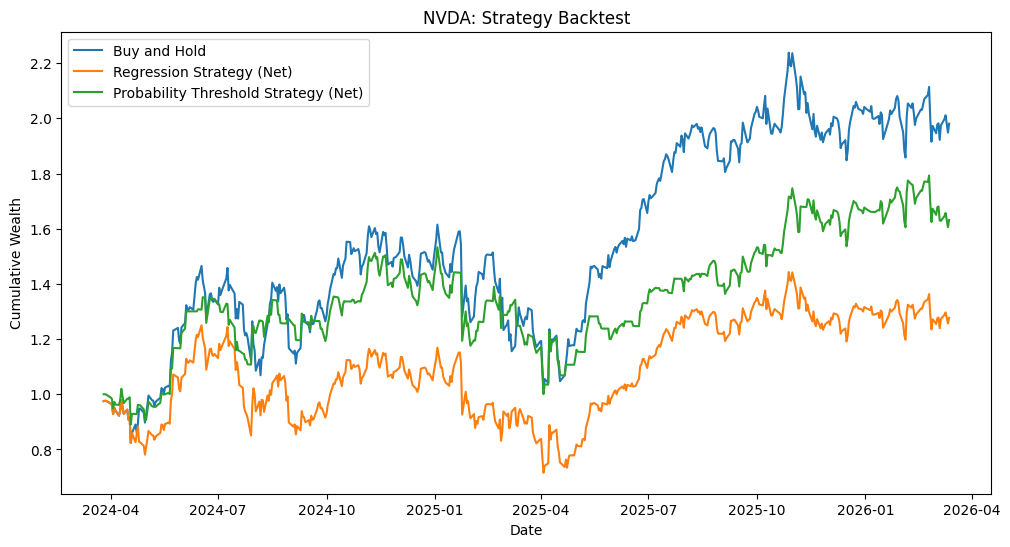

In [84]:
plt.figure(figsize=(12, 6))
plt.plot(buy_hold_curve, label="Buy and Hold")
plt.plot(strategy_curve_reg, label="Regression Strategy (Net)")
plt.plot(strategy_curve_prob, label="Probability Threshold Strategy (Net)")
plt.title(f"{ticker}: Strategy Backtest")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.show()

In [85]:
backtest_df = pd.DataFrame([
    {
        "Strategy": "Buy and Hold",
        "Sharpe": sharpe_ratio(buy_hold_ret),
        "Annualized Return": annualized_return(buy_hold_ret),
        "Max Drawdown": max_drawdown(buy_hold_curve)
    },
    {
        "Strategy": "Regression Strategy (Net)",
        "Sharpe": sharpe_ratio(strategy_ret_reg_net),
        "Annualized Return": annualized_return(strategy_ret_reg_net),
        "Max Drawdown": max_drawdown(strategy_curve_reg)
    },
    {
        "Strategy": "Probability Threshold Strategy (Net)",
        "Sharpe": sharpe_ratio(strategy_ret_prob_net),
        "Annualized Return": annualized_return(strategy_ret_prob_net),
        "Max Drawdown": max_drawdown(strategy_curve_prob)
    }
])

backtest_df

,Strategy,Sharpe,Annualized Return,Max Drawdown
0,Buy and Hold,0.953145,0.418097,-0.368810
1,Regression Strategy (Net),0.499748,0.133112,-0.427547
2,Probability Threshold Strategy (Net),0.801476,0.284444,-0.347299


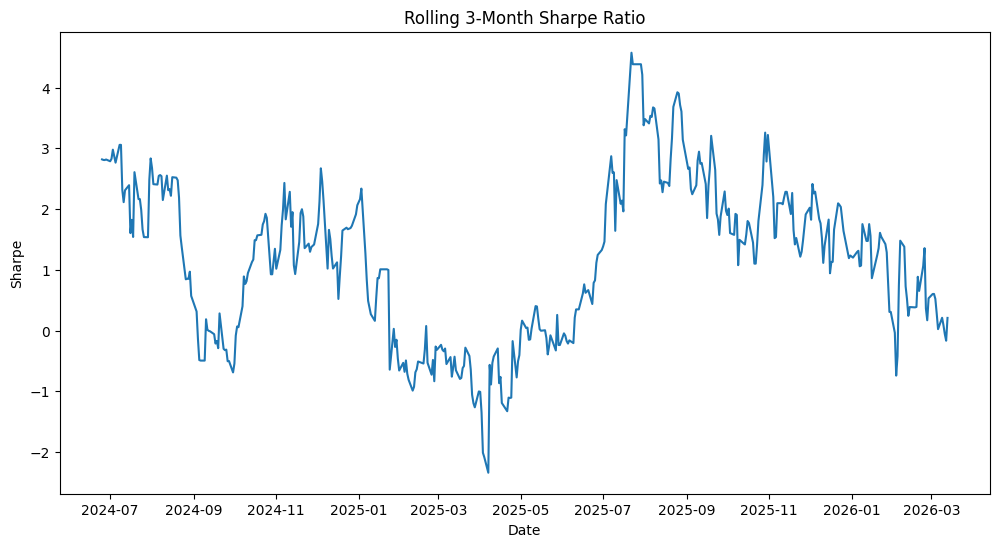

In [86]:
rolling_sharpe = strategy_ret_prob_net.rolling(63).apply(
    lambda x: np.sqrt(252) * x.mean() / (x.std() + 1e-12),
    raw=False
)

plt.figure(figsize=(12, 6))
plt.plot(rolling_sharpe)
plt.title("Rolling 3-Month Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.show()

In [87]:
def walk_forward_backtest(X, y, model_factory, initial_train_size=1000, step_size=20):
    preds = []
    actuals = []
    dates = []

    for start in range(initial_train_size, len(X) - step_size + 1, step_size):
        X_tr = X.iloc[:start]
        y_tr = y[:start]
        X_te = X.iloc[start:start + step_size]
        y_te = y[start:start + step_size]

        model = model_factory()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        preds.extend(pred)
        actuals.extend(y_te)
        dates.extend(X_te.index)

    pred_series = pd.Series(preds, index=dates)
    actual_series = pd.Series(actuals, index=dates)

    return pred_series, actual_series

In [88]:
wf_pred, wf_actual = walk_forward_backtest(
    X,
    y,
    model_factory=lambda: RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        max_depth=8,
        min_samples_leaf=10,
        n_jobs=-1
    ),
    initial_train_size=1000,
    step_size=20
)

report_regression("Walk-Forward Random Forest", wf_actual.values, wf_pred.values)


Walk-Forward Random Forest
MAE (return): 0.023800
R2  (return): -0.022073
Direction accuracy: 48.84%


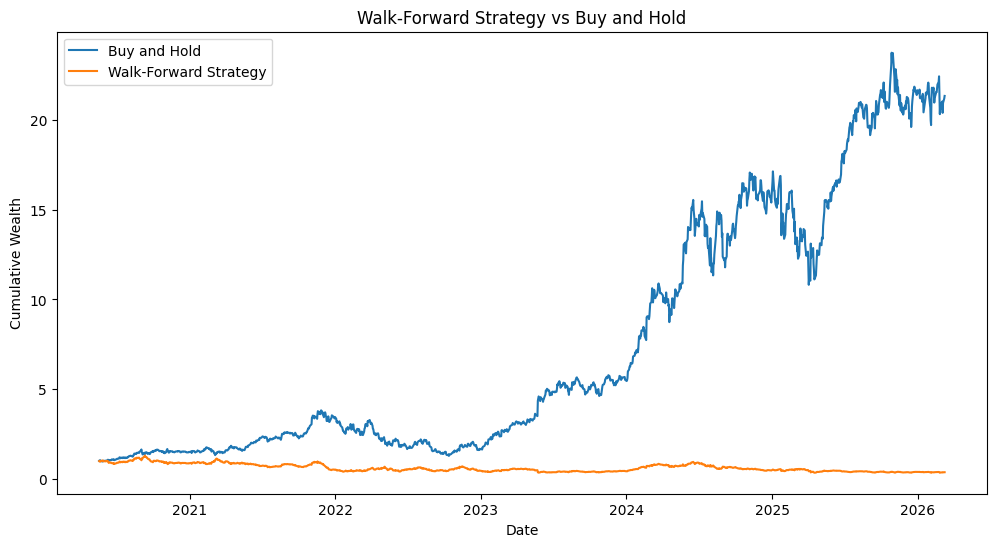

In [89]:
wf_signal = np.sign(wf_pred)
wf_strategy_ret = wf_signal * wf_actual

wf_curve = (1 + wf_strategy_ret).cumprod()
wf_market = (1 + wf_actual).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(wf_market, label="Buy and Hold")
plt.plot(wf_curve, label="Walk-Forward Strategy")
plt.title("Walk-Forward Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.show()

In [90]:
feat["regime_vol"] = feat["vol_20"]
median_vol = feat["regime_vol"].median()
feat["vol_regime"] = np.where(feat["regime_vol"] > median_vol, "High Vol", "Low Vol")

In [91]:
regime_test = feat.iloc[split:].copy()
regime_test["pred_rf"] = pred_rf
regime_test["actual"] = y_test
regime_test["signal"] = np.sign(pred_rf)
regime_test["strategy_ret"] = regime_test["signal"] * regime_test["actual"]

regime_summary = regime_test.groupby("vol_regime").agg(
    mean_return=("strategy_ret", "mean"),
    sharpe=("strategy_ret", lambda x: np.sqrt(252) * x.mean() / (x.std() + 1e-12)),
    hit_rate=("strategy_ret", lambda x: (x > 0).mean())
)

regime_summary

,mean_return,sharpe,hit_rate
vol_regime,,,
High Vol,0.000782,0.332039,0.500000
Low Vol,0.001638,1.135192,0.535865


In [92]:
def autocorr(x, lag=1):
    x = pd.Series(x).dropna()
    return x.autocorr(lag=lag)

resid_autocorr = pd.DataFrame({
    "lag": list(range(1, 11)),
    "autocorrelation": [autocorr(residuals, lag=i) for i in range(1, 11)]
})

resid_autocorr

,lag,autocorrelation
0,1,-0.076867
1,2,0.116379
2,3,-0.095044
3,4,-0.044509
4,5,-0.077807
5,6,0.040412
6,7,-0.072816
7,8,0.055340
8,9,-0.010616
9,10,-0.019904


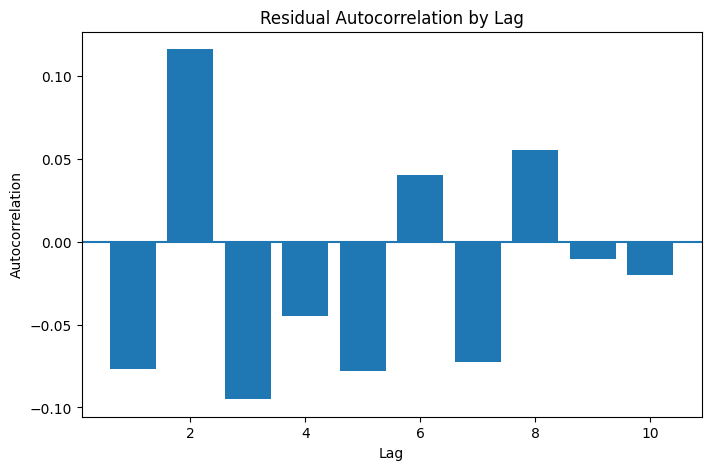

In [93]:
plt.figure(figsize=(8, 5))
plt.bar(resid_autocorr["lag"], resid_autocorr["autocorrelation"])
plt.axhline(0)
plt.title("Residual Autocorrelation by Lag")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

In [94]:
tree_preds = np.column_stack([tree.predict(X_test) for tree in rf.estimators_])
pred_std = tree_preds.std(axis=1)

uncertainty_df = pd.DataFrame({
    "pred": pred_rf,
    "actual": y_test,
    "uncertainty": pred_std
}, index=X_test.index)

uncertainty_df.head()

/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Decisio

,pred,actual,uncertainty
Date,,,
2024-03-26,0.004468,-0.024967,0.008683
2024-03-27,0.006177,0.001174,0.008479
2024-03-28,0.006079,0.000077,0.008781
2024-04-01,0.006521,-0.010082,0.008109
2024-04-02,0.006646,-0.005455,0.009115


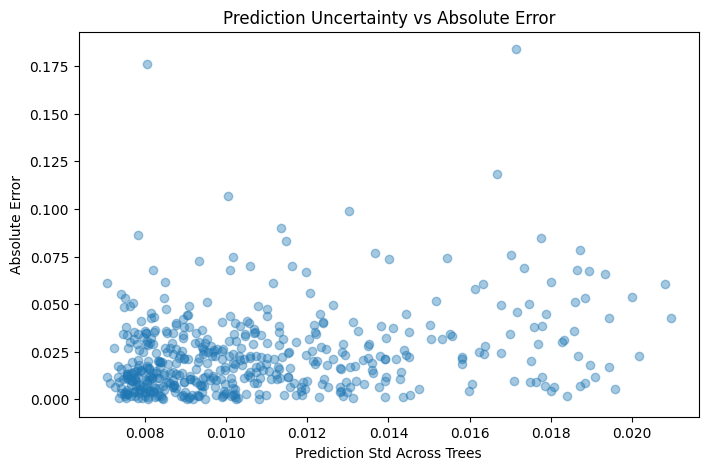

In [95]:
uncertainty_df["abs_error"] = np.abs(uncertainty_df["actual"] - uncertainty_df["pred"])

plt.figure(figsize=(8, 5))
plt.scatter(uncertainty_df["uncertainty"], uncertainty_df["abs_error"], alpha=0.4)
plt.title("Prediction Uncertainty vs Absolute Error")
plt.xlabel("Prediction Std Across Trees")
plt.ylabel("Absolute Error")
plt.show()

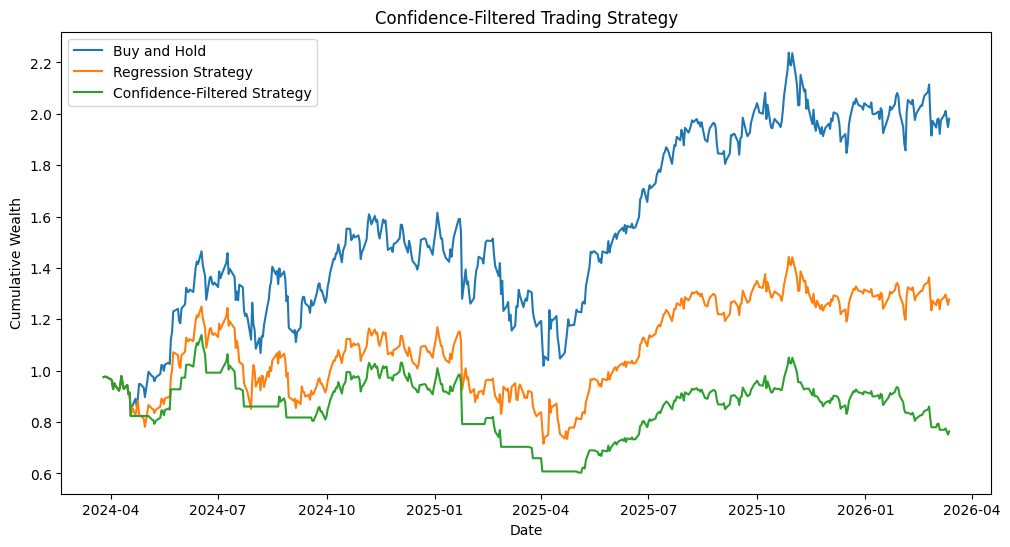

In [96]:
uncertainty_threshold = uncertainty_df["uncertainty"].quantile(0.7)

confident_signal = np.where(
    uncertainty_df["uncertainty"] <= uncertainty_threshold,
    np.sign(uncertainty_df["pred"]),
    0
)

confident_strategy_ret = confident_signal * uncertainty_df["actual"]
confident_curve = (1 + confident_strategy_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot((1 + pd.Series(y_test, index=X_test.index)).cumprod(), label="Buy and Hold")
plt.plot((1 + pd.Series(strategy_ret_reg_net, index=X_test.index)).cumprod(), label="Regression Strategy")
plt.plot(confident_curve, label="Confidence-Filtered Strategy")
plt.title("Confidence-Filtered Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.show()

In [97]:
window_size = 750
step = 125
importance_history = []

for end in range(window_size, len(X_train), step):
    X_sub = X_train.iloc[end - window_size:end]
    y_sub = y_train[end - window_size:end]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=8,
        min_samples_leaf=10,
        n_jobs=-1
    )
    model.fit(X_sub, y_sub)

    imp = pd.Series(model.feature_importances_, index=X_sub.columns)
    imp.name = X_sub.index[-1]
    importance_history.append(imp)

importance_history_df = pd.DataFrame(importance_history)
importance_history_df.head()

,ret1,ret_5,ret_10,ret_20,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_lag_6,...,vol_5,vol_10,vol_20,rsi_14,macd,atr_14,stoch_14,vol_ratio,bollinger_width,zscore_20
2019-05-20,0.050923,0.014872,0.019438,0.020375,0.047756,0.031819,0.053569,0.031402,0.014575,0.029817,...,0.029144,0.026496,0.025508,0.021879,0.046378,0.033734,0.051963,0.089314,0.020985,0.013964
2019-11-14,0.052497,0.022210,0.017248,0.019761,0.042720,0.032408,0.034945,0.031765,0.025398,0.041681,...,0.031203,0.026862,0.034032,0.027127,0.054226,0.038948,0.025726,0.053303,0.027214,0.016262
2020-05-15,0.085281,0.021905,0.019775,0.017406,0.048465,0.024337,0.042649,0.014643,0.032642,0.067729,...,0.042153,0.030759,0.025977,0.022971,0.035379,0.061690,0.011091,0.030260,0.037623,0.010663
2020-11-11,0.083769,0.032394,0.026450,0.018811,0.059364,0.027976,0.054593,0.020471,0.039815,0.052257,...,0.044738,0.055746,0.044257,0.011648,0.026013,0.025552,0.011877,0.031628,0.054968,0.006732
2021-05-13,0.080447,0.033891,0.023731,0.023269,0.061057,0.025040,0.043164,0.016032,0.042841,0.075266,...,0.043894,0.054920,0.035038,0.013405,0.019309,0.020105,0.011884,0.035597,0.051936,0.015772


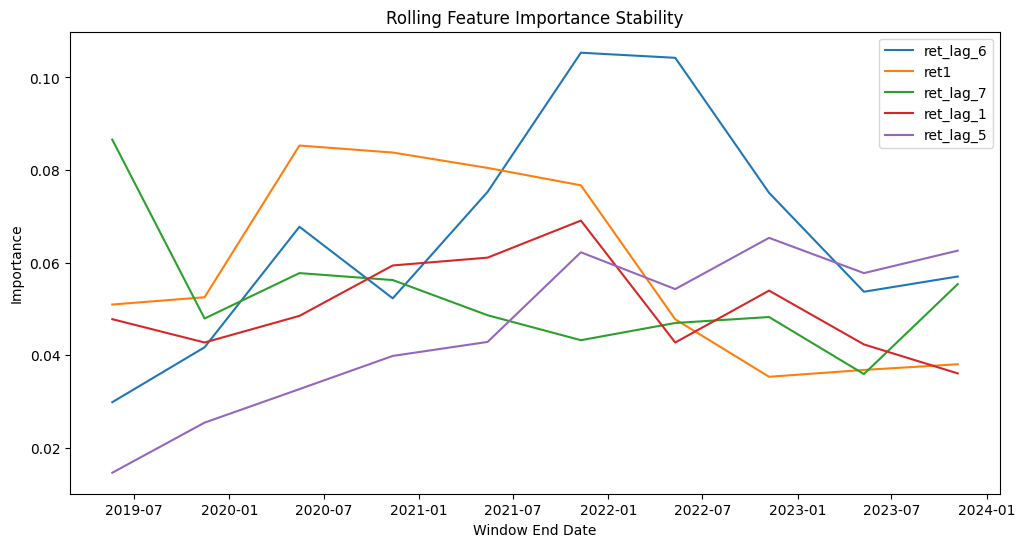

In [98]:
top_stable_features = importance_history_df.mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12, 6))
for col in top_stable_features:
    plt.plot(importance_history_df.index, importance_history_df[col], label=col)

plt.title("Rolling Feature Importance Stability")
plt.xlabel("Window End Date")
plt.ylabel("Importance")
plt.legend()
plt.show()

In [99]:
bucket_df = pd.DataFrame({
    "pred": pred_rf,
    "actual": y_test
}, index=X_test.index)

bucket_df["bucket"] = pd.qcut(bucket_df["pred"], 5, labels=False)

bucket_summary = bucket_df.groupby("bucket").agg(
    mean_pred=("pred", "mean"),
    mean_actual=("actual", "mean"),
    sharpe=("actual", lambda x: np.sqrt(252) * x.mean() / (x.std() + 1e-12))
)

bucket_summary

,mean_pred,mean_actual,sharpe
bucket,,,
0,0.001043,0.000426,0.175252
1,0.004879,0.002859,1.602538
2,0.005672,0.002613,1.806899
3,0.006191,-0.001189,-0.794446
4,0.007623,0.004640,1.901679


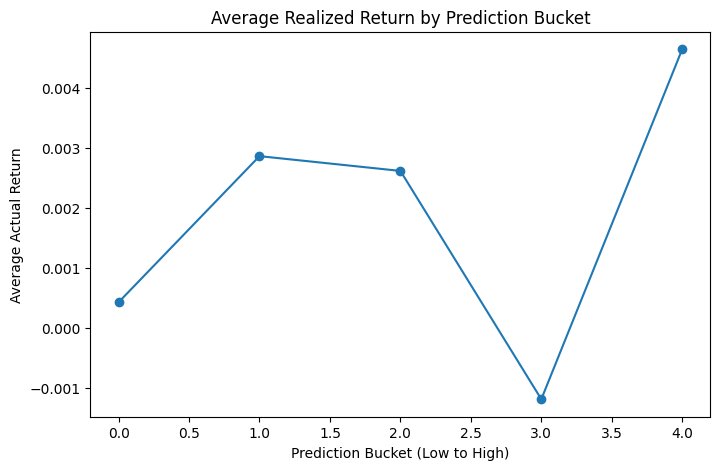

In [100]:
plt.figure(figsize=(8, 5))
plt.plot(bucket_summary.index, bucket_summary["mean_actual"], marker="o")
plt.title("Average Realized Return by Prediction Bucket")
plt.xlabel("Prediction Bucket (Low to High)")
plt.ylabel("Average Actual Return")
plt.show()

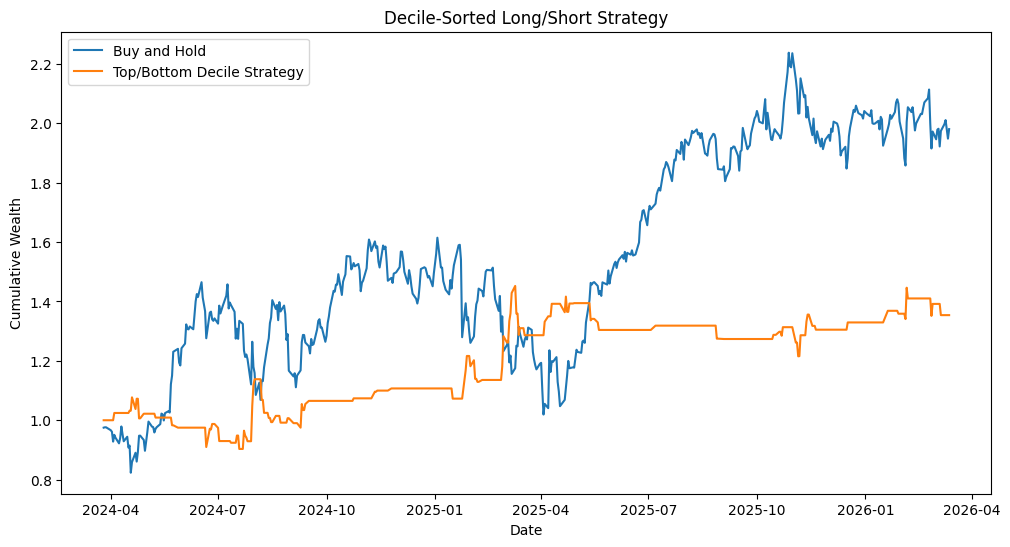

In [101]:
bucket_df["rank_pct"] = bucket_df["pred"].rank(pct=True)

decile_signal = np.where(bucket_df["rank_pct"] >= 0.9, 1,
                 np.where(bucket_df["rank_pct"] <= 0.1, -1, 0))

decile_strategy_ret = decile_signal * bucket_df["actual"]
decile_curve = (1 + pd.Series(decile_strategy_ret, index=bucket_df.index)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot((1 + buy_hold_ret).cumprod(), label="Buy and Hold")
plt.plot(decile_curve, label="Top/Bottom Decile Strategy")
plt.title("Decile-Sorted Long/Short Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.show()

In [102]:
advanced_backtest_df = pd.DataFrame([
    {
        "Strategy": "Buy and Hold",
        "Sharpe": sharpe_ratio(buy_hold_ret),
        "Annualized Return": annualized_return(buy_hold_ret),
        "Max Drawdown": max_drawdown((1 + buy_hold_ret).cumprod())
    },
    {
        "Strategy": "Regression Strategy",
        "Sharpe": sharpe_ratio(strategy_ret_reg_net),
        "Annualized Return": annualized_return(strategy_ret_reg_net),
        "Max Drawdown": max_drawdown((1 + strategy_ret_reg_net).cumprod())
    },
    {
        "Strategy": "Confidence Filtered",
        "Sharpe": sharpe_ratio(confident_strategy_ret),
        "Annualized Return": annualized_return(confident_strategy_ret),
        "Max Drawdown": max_drawdown(confident_curve)
    },
    {
        "Strategy": "Top/Bottom Decile",
        "Sharpe": sharpe_ratio(decile_strategy_ret),
        "Annualized Return": annualized_return(decile_strategy_ret),
        "Max Drawdown": max_drawdown(decile_curve)
    },
    {
        "Strategy": "Walk-Forward Strategy",
        "Sharpe": sharpe_ratio(wf_strategy_ret),
        "Annualized Return": annualized_return(wf_strategy_ret),
        "Max Drawdown": max_drawdown(wf_curve)
    }
])

advanced_backtest_df

,Strategy,Sharpe,Annualized Return,Max Drawdown
0,Buy and Hold,0.953145,0.418097,-0.368810
1,Regression Strategy,0.499748,0.133112,-0.427547
2,Confidence Filtered,-0.205085,-0.128851,-0.470889
3,Top/Bottom Decile,0.718227,0.167563,-0.163193
4,Walk-Forward Strategy,-0.077696,-0.156476,-0.734066


In [103]:
tickers = ["NVDA", "AAPL", "MSFT", "AMD", "AMZN"]
multi_results = []

for tk in tickers:
    temp_df = yf.download(tk, period="10y", auto_adjust=False)
    if temp_df.empty:
        continue

    temp_feat = make_features(temp_df)

    temp_feature_cols = [c for c in temp_feat.columns if c not in ["target_next_ret", "target_direction", "price"]]
    X_temp = temp_feat[temp_feature_cols]
    y_temp = temp_feat["target_next_ret"].values

    split_temp = int(len(temp_feat) * 0.8)
    X_tr, X_te = X_temp.iloc[:split_temp], X_temp.iloc[split_temp:]
    y_tr, y_te = y_temp[:split_temp], y_temp[split_temp:]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=8,
        min_samples_leaf=10,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    signal = np.sign(pred)
    strat_ret = signal * y_te

    multi_results.append({
        "Ticker": tk,
        "MAE": mean_absolute_error(y_te, pred),
        "R2": r2_score(y_te, pred),
        "Direction Accuracy": direction_accuracy(y_te, pred),
        "Sharpe": sharpe_ratio(strat_ret)
    })

multi_results_df = pd.DataFrame(multi_results)
multi_results_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Ticker,MAE,R2,Direction Accuracy,Sharpe
0,NVDA,0.022976,-0.038422,0.531440,0.485749
1,AAPL,0.012070,-0.011420,0.494929,0.989766
2,MSFT,0.010580,-0.070182,0.509128,-0.238699
3,AMD,0.024688,-0.021643,0.474645,-0.430470
4,AMZN,0.014622,-0.014004,0.496957,0.404640


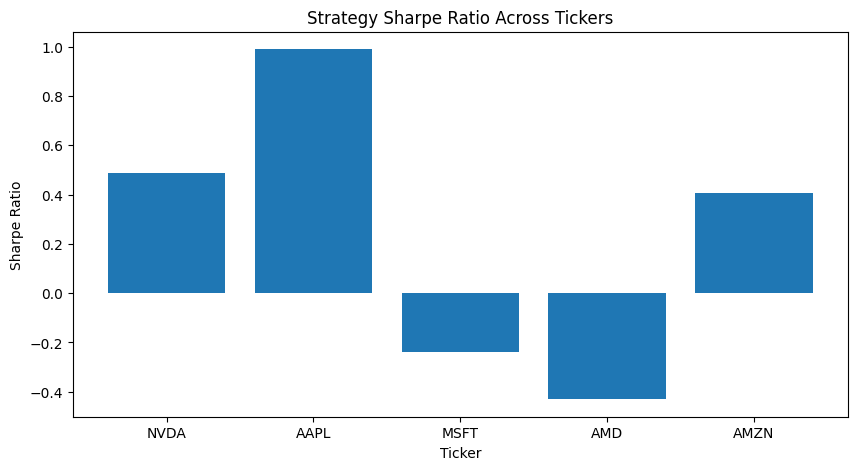

In [104]:
plt.figure(figsize=(10, 5))
plt.bar(multi_results_df["Ticker"], multi_results_df["Sharpe"])
plt.title("Strategy Sharpe Ratio Across Tickers")
plt.xlabel("Ticker")
plt.ylabel("Sharpe Ratio")
plt.show()